# MKP pretrained reproduction

This notebook runs the unified DeepACO reproduction entry point for this problem. It writes logs, raw JSON, Markdown tables, and PNG figures to the repository-level output folders.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'pretrained').exists() else cwd.parent
sys.path.insert(0, str(ROOT))

from scripts.reproduce_problem import run_problem

PROBLEM = 'mkp'
DEVICE = 'auto'          # 'auto', 'cpu', 'cuda', or 'cuda:0'
SEED = 12345
LIMIT_INSTANCES = None   # set to a small integer for a quick smoke test
SIZES = None             # e.g. [20] or None for all configured scales
T_ACO = None             # e.g. [1, 10] or None for paper-style checkpoints
METHODS = None           # e.g. ['deepaco'] or ['deepaco', 'aco']
INCLUDE_BASELINE = True


e:\DeepAoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw = run_problem(
    PROBLEM,
    sizes=SIZES,
    t_aco=T_ACO,
    methods=METHODS,
    limit_instances=LIMIT_INSTANCES,
    device=DEVICE,
    seed=SEED,
    include_baseline=INCLUDE_BASELINE,
)
raw['outputs']


[2026-05-11T09:46:02] Starting MKP reproduction
[2026-05-11T09:46:02] sizes=[300, 500], t_aco=[1, 10, 20, 30, 40, 50, 100], methods=['deepaco', 'aco'], device=cpu
[2026-05-11T09:46:05] MKP300: 100/100 instances
[2026-05-11T10:26:06] Finished MKP 300 DeepACO-GNN in 2400.75s
[2026-05-11T10:59:44] Finished MKP 300 ACO in 2017.85s
[2026-05-11T10:59:44] MKP500: 100/100 instances
[2026-05-11T12:00:48] Finished MKP 500 DeepACO-GNN in 3664.66s
[2026-05-11T12:45:35] Finished MKP 500 ACO in 2686.56s
[2026-05-11T12:45:36] Wrote raw results: results/raw/mkp_results.json
[2026-05-11T12:45:36] Wrote table: results/tables/mkp_table.md
[2026-05-11T12:45:36] Wrote figure: results/figures/mkp_comparison.png


{'raw': 'results/raw/mkp_results.json',
 'table': 'results/tables/mkp_table.md',
 'figure': 'results/figures/mkp_comparison.png',
 'log': 'logs/mkp.log'}

# MKP Reproduction Table

- Metric: average objective (higher is better)
- Instances per completed row: see `instances` column
- Device: cpu

| scale | method | status | instances | duration_s | T=1 | T=10 | T=20 | T=30 | T=40 | T=50 | T=100 | gap_vs_aco_last |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 300 | DeepACO-GNN | ok | 100 | 2400.75 | 57.8002 | 59.0085 | 59.4802 | 59.8163 | 59.995 | 60.1422 | 60.7821 | +3.46% |
| 300 | ACO | ok | 100 | 2017.85 | 44.2943 | 47.2897 | 48.8579 | 50.9827 | 53.367 | 55.4772 | 58.7482 |  |
| 500 | DeepACO-GNN | ok | 100 | 3664.66 | 98.5138 | 99.7143 | 100.166 | 100.649 | 100.938 | 101.18 | 101.778 | +5.85% |
| 500 | ACO | ok | 100 | 2686.56 | 70.3979 | 74.1686 | 76.2566 | 79.3048 | 83.7807 | 87.7628 | 96.1524 |  |


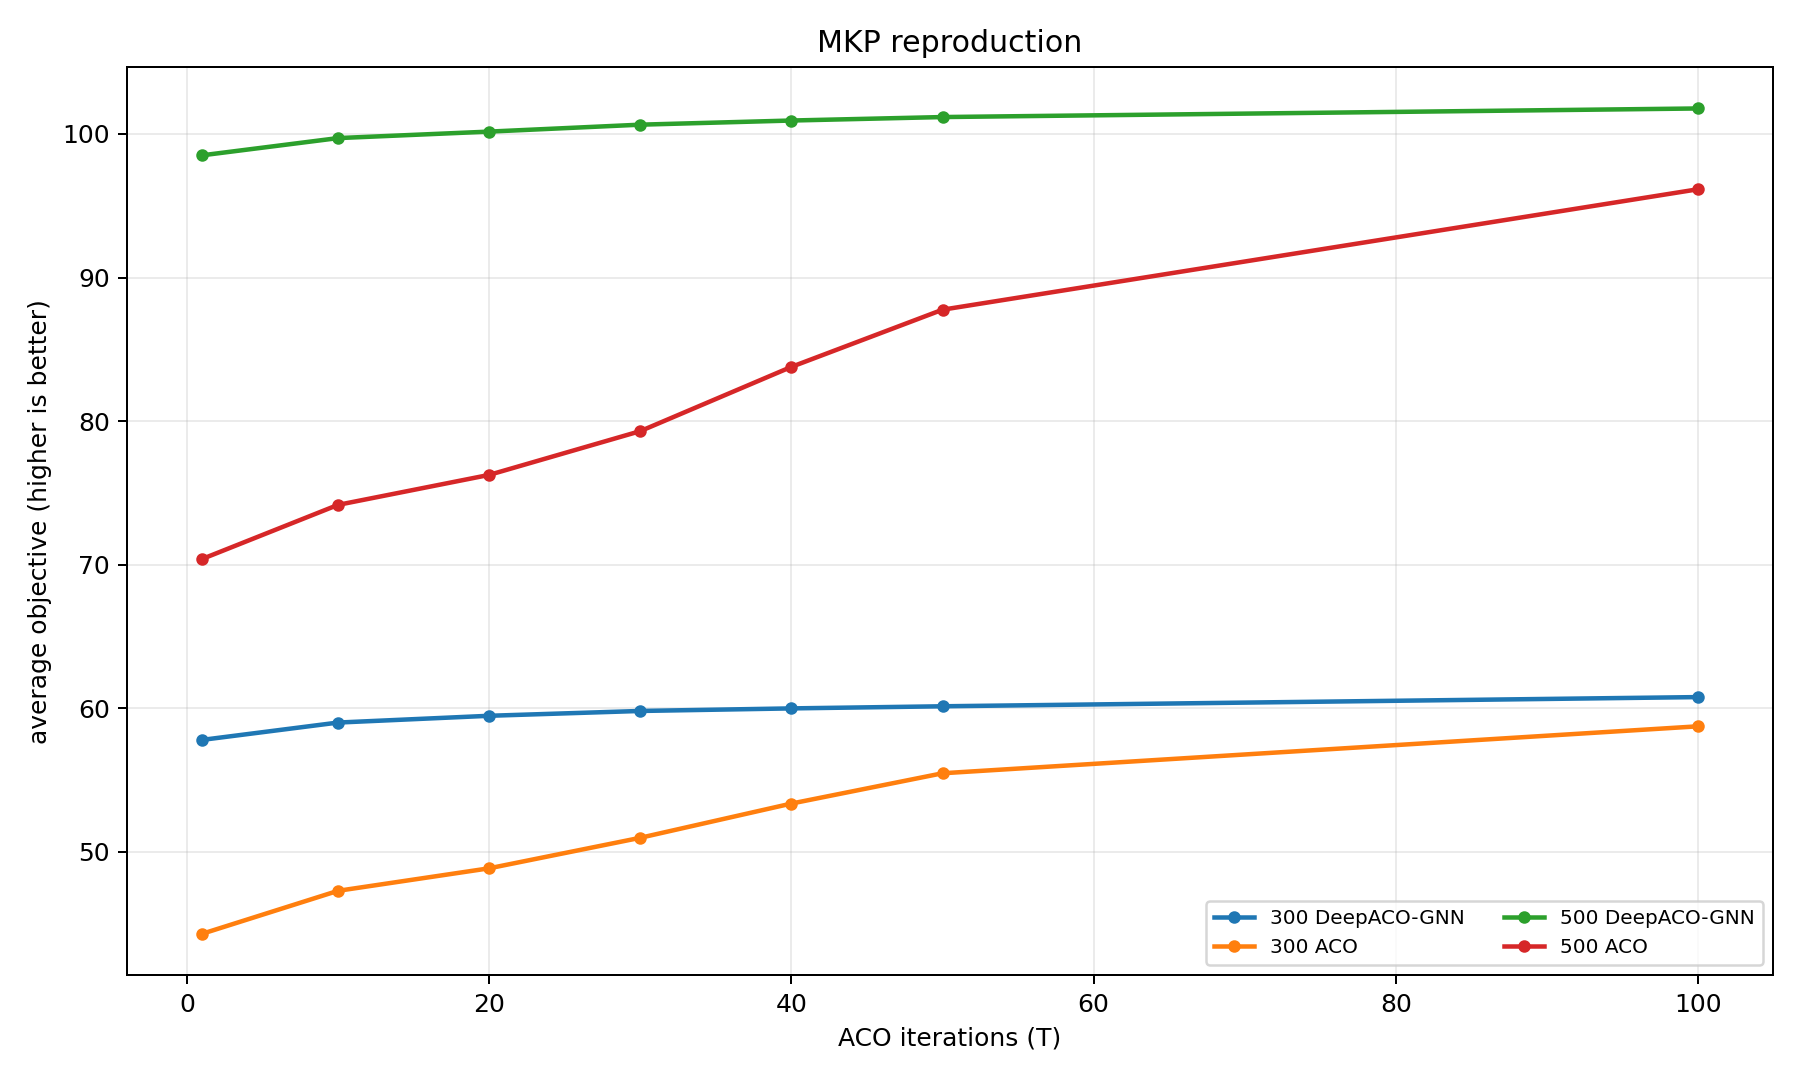

In [3]:
from IPython.display import Image, Markdown, display

outputs = raw['outputs'] if 'raw' in globals() else {
    'table': f'results/tables/{PROBLEM}_table.md',
    'figure': f'results/figures/{PROBLEM}_comparison.png',
}

table_path = ROOT / outputs['table']
figure_path = ROOT / outputs['figure']

display(Markdown(table_path.read_text(encoding='utf-8')))
display(Image(filename=str(figure_path)))


[paper] MKP300 ACO AS
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 ACO in 2069.16s
[paper] MKP300 DeepACO AS
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 DeepACO-GNN in 2455.34s
[paper] MKP300 ACO Elitist
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 ACO in 2124.56s
[paper] MKP300 DeepACO Elitist
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 DeepACO-GNN in 2620.91s
[paper] MKP300 ACO MAX-MIN
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 ACO in 2088.16s
[paper] MKP300 DeepACO MAX-MIN
[paper] MKP300: 100/100 instances
[paper] Finished MKP 300 DeepACO-GNN in 3679.87s
[paper] wrote results/paper_data/mkp_paper_real_curves.csv
[paper] MKP500 ACO AS
[paper] MKP500: 100/100 instances
[paper] Finished MKP 500 ACO in 5388.59s
[paper] MKP500 DeepACO AS
[paper] MKP500: 100/100 instances
[paper] Finished MKP 500 DeepACO-GNN in 6050.80s
[paper] MKP500 ACO Elitist
[paper] MKP500: 100/100 instances
[paper] Finished MKP 500 ACO in 3947

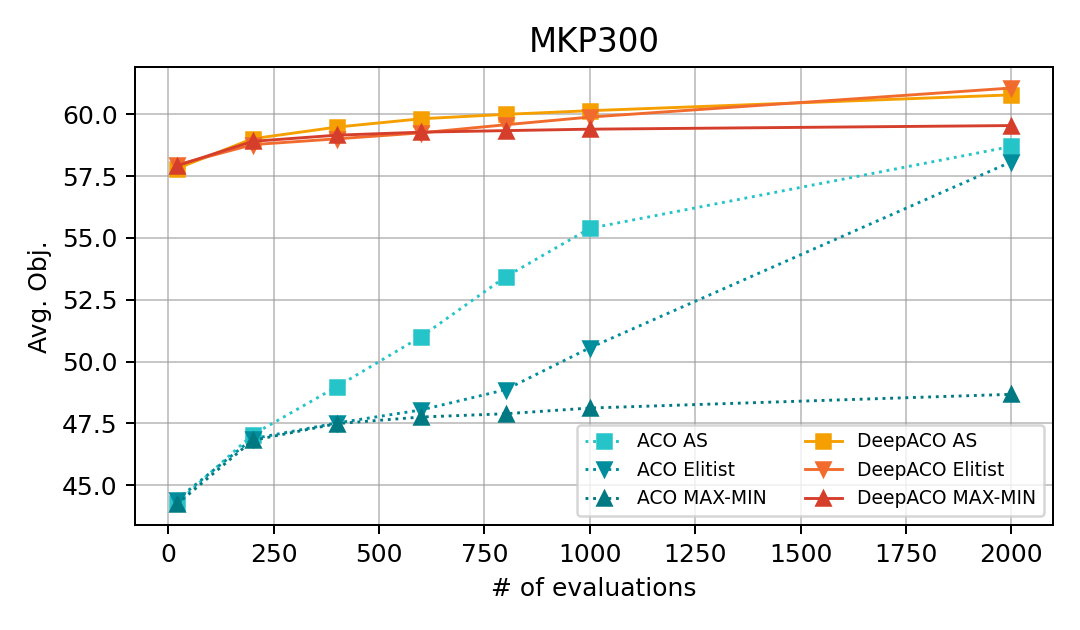

results/paper_figures/MKP500.png


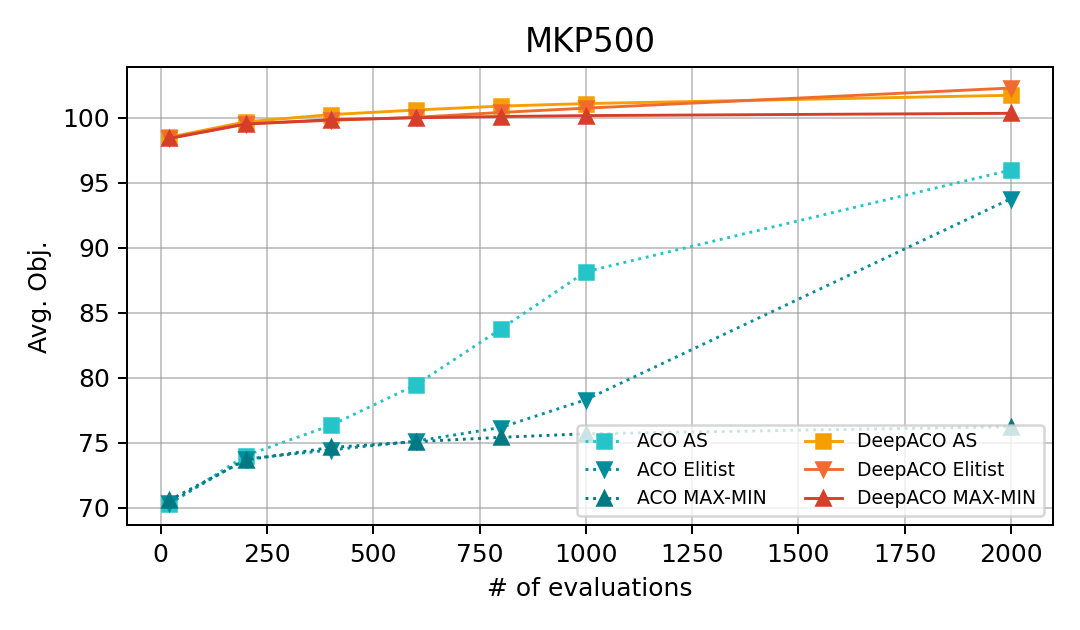

In [2]:
# Paper-style DeepACO comparison figures from pretrained models
from pathlib import Path
from contextlib import contextmanager
import os

os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.mplconfig'))
(ROOT / '.mplconfig').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

from scripts.reproduce_problem import (
    PROBLEMS,
    RUNNERS,
    problem_context,
    resolve_device,
    normalize_int_sequence,
    set_reproducibility,
)

# Set these before running this cell if you want a shorter smoke test.
PAPER_SIZES = None              # None -> paper/default sizes for this PROBLEM
PAPER_T_ACO = None              # None -> [1, 10, 20, 30, 40, 50, 100]
PAPER_LIMIT_INSTANCES = LIMIT_INSTANCES
PAPER_FORCE_RECOMPUTE = False

PAPER_VARIANTS = {
    'AS': {'elitist': False, 'min_max': False},
    'Elitist': {'elitist': True, 'min_max': False},
    'MAX-MIN': {'elitist': True, 'min_max': True},
}
PAPER_METHODS = {'aco': 'ACO', 'deepaco': 'DeepACO'}
PAPER_STYLES = {
    ('ACO', 'AS'): {'color': '#25c4c8', 'marker': 's', 'linestyle': ':'},
    ('ACO', 'Elitist'): {'color': '#008d9c', 'marker': 'v', 'linestyle': ':'},
    ('ACO', 'MAX-MIN'): {'color': '#007982', 'marker': '^', 'linestyle': ':'},
    ('DeepACO', 'AS'): {'color': '#f5a000', 'marker': 's', 'linestyle': '-'},
    ('DeepACO', 'Elitist'): {'color': '#f26b2e', 'marker': 'v', 'linestyle': '-'},
    ('DeepACO', 'MAX-MIN'): {'color': '#d53e2a', 'marker': '^', 'linestyle': '-'},
}


def paper_t_aco(spec):
    default = [1, 10, 20, 30, 40, 50, 100]
    return normalize_int_sequence(PAPER_T_ACO, default, 'PAPER_T_ACO')


@contextmanager
def patched_aco_variant(problem, variant_params):
    import aco as aco_module

    attr = 'ACO_RCPSP' if problem == 'rcpsp' else 'ACO'
    original = getattr(aco_module, attr)

    class PatchedACO(original):
        def __init__(self, *args, **kwargs):
            kwargs['elitist'] = variant_params['elitist']
            kwargs['min_max'] = variant_params['min_max']
            super().__init__(*args, **kwargs)

    setattr(aco_module, attr, PatchedACO)
    try:
        yield
    finally:
        setattr(aco_module, attr, original)


def expected_rows_for_size(size, spec, t_aco):
    evals = [t * spec['n_ants'] for t in t_aco]
    return {
        (int(size), algorithm, variant, int(evaluations))
        for algorithm in PAPER_METHODS.values()
        for variant in PAPER_VARIANTS
        for evaluations in evals
    }


def cache_has_size(df, size, spec, t_aco):
    required = {'scale', 'algorithm', 'variant', 'evaluations', 'avg_obj', 'source'}
    if df.empty or not required.issubset(df.columns):
        return False
    subset = df[(df['scale'].astype(int) == int(size)) & (df['source'] == 'pretrained')]
    actual = {
        (int(row.scale), str(row.algorithm), str(row.variant), int(row.evaluations))
        for row in subset.itertuples(index=False)
    }
    return expected_rows_for_size(size, spec, t_aco).issubset(actual)


def run_real_paper_size(problem, size, spec, t_aco, limit_instances, device):
    rows = []

    def log(message):
        print(f'[paper] {message}')

    for variant, variant_params in PAPER_VARIANTS.items():
        for method, algorithm in PAPER_METHODS.items():
            log(f"{spec['display']}{size} {algorithm} {variant}")
            set_reproducibility(SEED)
            with problem_context(problem, spec['cwd']):
                with patched_aco_variant(problem, variant_params):
                    runs = RUNNERS[problem](
                        spec,
                        [size],
                        [method],
                        t_aco,
                        limit_instances,
                        device,
                        log,
                    )

            if len(runs) != 1:
                raise RuntimeError(f'Expected one run for {problem} {size} {algorithm} {variant}, got {len(runs)}')
            run = runs[0]
            if run.get('status') != 'ok':
                raise RuntimeError(f"{problem} {size} {algorithm} {variant} failed: {run.get('error')}")

            for t, value in zip(run['t_aco'], run['values']):
                rows.append({
                    'problem': problem,
                    'problem_display': spec['display'],
                    'scale': int(size),
                    'algorithm': algorithm,
                    'variant': variant,
                    't_aco': int(t),
                    'evaluations': int(t) * int(spec['n_ants']),
                    'avg_obj': float(value),
                    'instances': int(run['instances']),
                    'device': device,
                    'source': 'pretrained',
                })
    return pd.DataFrame(rows)


def load_or_run_real_paper_data(problem, sizes, spec, t_aco, limit_instances, device):
    data_dir = ROOT / 'results' / 'paper_data'
    data_dir.mkdir(parents=True, exist_ok=True)
    csv_path = data_dir / f'{problem}_paper_real_curves.csv'

    if csv_path.is_file() and not PAPER_FORCE_RECOMPUTE:
        cached = pd.read_csv(csv_path)
    else:
        cached = pd.DataFrame()

    frames = []
    for size in sizes:
        if not PAPER_FORCE_RECOMPUTE and cache_has_size(cached, size, spec, t_aco):
            print(f'[paper] using cached pretrained data for {spec["display"]}{size}')
            frames.append(cached[cached['scale'].astype(int) == int(size)].copy())
            continue

        fresh = run_real_paper_size(problem, size, spec, t_aco, limit_instances, device)
        frames.append(fresh)
        if cached.empty:
            cached = fresh.copy()
        else:
            cached = cached[cached['scale'].astype(int) != int(size)]
            cached = pd.concat([cached, fresh], ignore_index=True)
        cached.to_csv(csv_path, index=False)
        print(f'[paper] wrote {csv_path.relative_to(ROOT).as_posix()}')

    return pd.concat(frames, ignore_index=True)


def plot_paper_figure(df, spec, scale, output_path):
    fig, ax = plt.subplots(figsize=(6.0, 3.5))
    for algorithm in ['ACO', 'DeepACO']:
        for variant in ['AS', 'Elitist', 'MAX-MIN']:
            curve = df[
                (df['scale'].astype(int) == int(scale))
                & (df['algorithm'] == algorithm)
                & (df['variant'] == variant)
            ].sort_values('evaluations')
            if curve.empty:
                continue
            style = PAPER_STYLES[(algorithm, variant)]
            ax.plot(
                curve['evaluations'],
                curve['avg_obj'],
                label=f'{algorithm} {variant}',
                color=style['color'],
                marker=style['marker'],
                linestyle=style['linestyle'],
                linewidth=1.15,
                markersize=5.5,
            )

    ax.set_title(f"{spec['display']}{scale}", fontsize=13)
    ax.set_xlabel('# of evaluations')
    ax.set_ylabel('Avg. Obj.')
    ax.grid(True, color='#9a9a9a', alpha=0.55, linewidth=0.8)
    ax.legend(fontsize=7.5, ncol=2, frameon=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.close(fig)


spec = PROBLEMS[PROBLEM]
sizes = normalize_int_sequence(PAPER_SIZES, spec['sizes'], 'PAPER_SIZES')
t_aco = paper_t_aco(spec)
device = resolve_device(DEVICE, spec['device'])

paper_df = load_or_run_real_paper_data(PROBLEM, sizes, spec, t_aco, PAPER_LIMIT_INSTANCES, device)

output_dir = ROOT / 'results' / 'paper_figures'
output_dir.mkdir(parents=True, exist_ok=True)

for scale in sizes:
    figure_path = output_dir / f"{spec['display']}{scale}.png"
    plot_paper_figure(paper_df, spec, scale, figure_path)
    print(figure_path.relative_to(ROOT).as_posix())
    display(Image(filename=str(figure_path)))
